In [ ]:
!pip install scanpy

In [ ]:
from google.colab import drive
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("/content/drive/MyDrive/Master/TFM/data_ultima_parte/datasets/Norman2019_prep_new.h5ad")

print(adata)
print("\n--- OBS (metadatos células) ---")
print(adata.obs.columns.tolist())

print("\n--- VAR (genes) ---")
print(adata.var.columns.tolist())

print("\n--- OBSM ---")
print(list(adata.obsm.keys()))

print("\n--- LAYERS ---")
print(list(adata.layers.keys()))

print("\n--- UNS ---")
print(list(adata.uns.keys()))

AnnData object with n_obs × n_vars = 108497 × 5000
    obs: 'cov_drug_dose_name', 'dose_val', 'control', 'condition', 'guide_identity', 'drug_dose_name', 'cell_type', 'split', 'split1', 'split2', 'split3', 'split4', 'split5', 'split6', 'split7', 'split8', 'split9', 'split10', 'split11', 'split12', 'split13', 'split14', 'split15', 'split16', 'split17', 'split18', 'split19', 'split20', 'split21', 'split22', 'split23', 'split24', 'split25'
    var: 'gene_symbols', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'rank_genes_groups_cov'
    layers: 'counts', None (.X)

--- OBS (metadatos células) ---
['cov_drug_dose_name', 'dose_val', 'control', 'condition', 'guide_identity', 'drug_dose_name', 'cell_type', 'split', 'split1', 'split2', 'split3', 'split4', 'split5', 'split6', 'split7', 'split8', 'split9', 'split10', 'split11', 'split12', 'split13', 'split14', 'split15', 'split16', 'split17', 'split18', 'split19', 'split20', 'split21', 'split22', 'split23', 'split

In [ ]:
# Distribución de condiciones
print(adata.obs['condition'].value_counts())
print(f"\nNº condiciones únicas: {adata.obs['condition'].nunique()}")

# Splits
print("\nDistribución split principal:")
print(adata.obs['split'].value_counts())

# Controles vs perturbados
print("\nControl vs perturbado:")
print(adata.obs['control'].value_counts())

# Counts
import scipy.sparse as sp
print(f"\nTipo de matrix X: {type(adata.X)}")
print(f"Tipo de layer counts: {type(adata.layers['counts'])}")

condition
ctrl             8907
CEBPE+RUNX1T1    1219
KLF1+ctrl        1197
TBX3+TBX2        1167
SLC4A1+ctrl      1000
                 ... 
CBL+UBASH3A        64
CEBPB+CEBPA        64
C3orf72+FOXL2      59
JUN+CEBPB          59
JUN+CEBPA          54
Name: count, Length: 284, dtype: int64

Nº condiciones únicas: 284

Distribución split principal:
split
train    97647
test     10848
ood          2
Name: count, dtype: int64

Control vs perturbado:
control
0    99590
1     8907
Name: count, dtype: int64

Tipo de matrix X: <class 'scipy.sparse._csr.csr_matrix'>
Tipo de layer counts: <class 'scipy.sparse._csr.csr_matrix'>


El split OOD (Out-Of-Distribution) es clave — son perturbaciones que el modelo nunca verá

In [ ]:
# Separar perturbaciones simples vs dobles
single = adata.obs[~adata.obs['condition'].str.contains(r'\+') |
                    adata.obs['condition'].str.contains('ctrl')]
double = adata.obs[adata.obs['condition'].str.contains(r'\+') &
                   ~adata.obs['condition'].str.contains('ctrl')]

print(f"Perturbaciones simples: {single['condition'].nunique()}")
print(f"Perturbaciones dobles:  {double['condition'].nunique()}")

# Ver qué hay en OOD (el modelo no ve)
ood_conditions = adata.obs[adata.obs['split'] == 'ood']['condition'].unique()
print(f"\nCondiciones OOD ({len(ood_conditions)}):")
print(ood_conditions[:20])

Perturbaciones simples: 153
Perturbaciones dobles:  131

Condiciones OOD (2):
['KLF1+MAP2K6', 'ARID1A+ctrl']
Categories (284, str): ['AHR+FEV', 'AHR+KLF1', 'AHR+ctrl', 'ARID1A+ctrl', ..., 'ZC3HAV1+HOXC13',
                        'ZC3HAV1+ctrl', 'ZNF318+FOXL2', 'ZNF318+ctrl']


In [ ]:
# Los 4 genes individuales que componen las OOD
ood_genes = ['DUSP9', 'MAPK1', 'ETS2', 'CBL', 'CNN1']

for gene in ood_genes:
    # Buscar condiciones en train que contengan este gen
    train_conds = adata.obs[adata.obs['split'] == 'train']['condition']
    aparece = train_conds[train_conds.str.contains(gene)].unique()
    print(f"{gene}: {list(aparece)[:5]}")

DUSP9: ['DUSP9+ctrl', 'DUSP9+MAPK1', 'DUSP9+ETS2', 'DUSP9+PRTG', 'DUSP9+IGDCC3']
MAPK1: ['DUSP9+MAPK1', 'IGDCC3+MAPK1', 'MAPK1+PRTG', 'MAPK1+ctrl', 'ctrl+MAPK1']
ETS2: ['ETS2+MAP7D1', 'TGFBR2+ETS2', 'ETS2+IGDCC3', 'ctrl+ETS2', 'DUSP9+ETS2']
CBL: ['CBL+PTPN9', 'CBL+ctrl', 'CBL+UBASH3A', 'CBL+CNN1', 'CBL+UBASH3B']
CNN1: ['ctrl+CNN1', 'ETS2+CNN1', 'CNN1+MAPK1', 'CNN1+ctrl', 'CNN1+UBASH3A']


El modelo nunca ve la combinación, pero sí cada gen por separado

In [ ]:
# Separamos los datos de train , test y ODD
train_idx = adata.obs['split'] == 'train'
test_idx = adata.obs['split'] == 'test'
ood_idx = adata.obs['split'] == 'ood'

adata_train = adata[train_idx].copy()
adata_test = adata[test_idx].copy()
adata_ood = adata[ood_idx].copy()

In [ ]:
adata_ood.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 863 stored elements and shape (2, 5000)>

In [ ]:
adata_train.obs

,cov_drug_dose_name,dose_val,control,condition,guide_identity,drug_dose_name,cell_type,split,split1,split2,...,split16,split17,split18,split19,split20,split21,split22,split23,split24,split25
index,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAAGAAGC-1,A549_ctrl_1,1,1,ctrl,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,ctrl_1,A549,train,train,train,...,train,train,train,train,train,train,train,train,train,train
AAACCTGAGGCATGTG-1,A549_TSC22D1+ctrl_1+1,1+1,0,TSC22D1+ctrl,TSC22D1_NegCtrl0__TSC22D1_NegCtrl0,TSC22D1+ctrl_1+1,A549,train,train,train,...,train,train,train,train,train,train,train,train,train,train
AAACCTGAGGCCCTTG-1,A549_KLF1+MAP2K6_1+1,1+1,0,KLF1+MAP2K6,KLF1_MAP2K6__KLF1_MAP2K6,KLF1+MAP2K6_1+1,A549,train,train,train,...,ood,ood,ood,ood,ood,train,train,ood,train,train
AAACCTGCACGAAGCA-1,A549_ctrl_1,1,1,ctrl,NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0,ctrl_1,A549,train,test,train,...,train,train,train,train,train,train,train,train,test,test
AAACCTGCAGACGTAG-1,A549_CEBPE+RUNX1T1_1+1,1+1,0,CEBPE+RUNX1T1,CEBPE_RUNX1T1__CEBPE_RUNX1T1,CEBPE+RUNX1T1_1+1,A549,train,train,train,...,train,train,train,train,train,train,train,ood,train,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCACTCCTG-8,A549_MAP2K6+IKZF3_1+1,1+1,0,MAP2K6+IKZF3,MAP2K6_IKZF3__MAP2K6_IKZF3,MAP2K6+IKZF3_1+1,A549,train,train,train,...,ood,ood,ood,ood,train,ood,train,ood,train,train
TTTGTCATCCACTCCA-8,A549_CELF2+ctrl_1+1,1+1,0,CELF2+ctrl,CELF2_NegCtrl0__CELF2_NegCtrl0,CELF2+ctrl_1+1,A549,train,train,train,...,train,train,train,test,train,train,train,train,train,train
TTTGTCATCCCAACGG-8,A549_BCORL1+ctrl_1+1,1+1,0,BCORL1+ctrl,BCORL1_NegCtrl0__BCORL1_NegCtrl0,BCORL1+ctrl_1+1,A549,train,test,train,...,train,train,train,train,train,train,train,train,train,train


- 'condition' o 'guide_identity': Te dirán exactamente qué gen fue editado (KO) o qué perturbación recibió esa célula concreta.

- 'drug_dose_name' y 'dose_val': Te indicarán qué fármaco y qué dosis se aplicó.

- 'control': Es una columna booleana (o binaria) que te dice si la célula pertenece al grupo de control (no se le hizo nada) o si fue intervenida. Algunas celulas pasan por el eperimento siendo controles y otras intervenidas, por eso esta columna.


# Pipeline :
1. Autoencoder :
Su único trabajo es aprender a comprimir y descomprimir cualquier estado celular por eso lo entrenamos con todas las celulas mezcladas (intervenidas o controles)

2. Modelo de difusion :
Una vez entrenado el AE usamos un modelo de diff que empuje el espacio latente de las celulas control hacia el espacio latente de estado intervenido sumandole el vector de intervencion (condition) .

3. Descompresion : Una vez movido en el espacio latente el AE sera capaz de descomprimir la celula a 5000 genes originales y tendremos nuestra prediccion de celula intervenida usando el vector de intervencion.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Train y val split
X_train_split, X_val_split = train_test_split(
    adata_train.X,
    test_size=0.1,
    random_state=42
)

# Pasamos a tensor y a dataset
X_train_tensor = torch.tensor(X_train_split.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_split.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(adata_test.X.toarray(),dtype=torch.float32)
X_ood_tensor = torch.tensor(adata_ood.X.toarray(),dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)

# Creamos los dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de validación: {len(val_loader)}")

Batches de entrenamiento: 343
Batches de validación: 39


In [ ]:
import torch.nn as nn

class AutoencoderSC(nn.Module):
    def __init__(self, n_genes=5000):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoencoderSC(n_genes=5000).to(device)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
loss_fn_ae = nn.SmoothL1Loss()

epochs_ae = 100

for epoch in range(epochs_ae):
    # ENTRENAMIENTO
    autoencoder.train()
    loss_total = 0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)

        x_pred, z = autoencoder(x_batch)
        loss = loss_fn_ae(x_pred, x_batch)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        loss_total += loss.item()

    # VALIDACIÓN
    autoencoder.eval()
    val_loss_total = 0
    with torch.no_grad():
        for (x_val,) in val_loader:
            x_val = x_val.to(device)

            x_pred_val, _ = autoencoder(x_val)
            val_loss = loss_fn_ae(x_pred_val, x_val)

            val_loss_total += val_loss.item()


    if (epoch + 1) % 10 == 0:
        train_loss_avg = loss_total / len(train_loader)
        val_loss_avg = val_loss_total / len(val_loader)
        print(f"AE Epoch [{epoch+1}/{epochs_ae}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")

AE Epoch [10/100] | Train Loss: 0.0149 | Validation Loss: 0.0142
AE Epoch [20/100] | Train Loss: 0.0136 | Validation Loss: 0.0132
AE Epoch [30/100] | Train Loss: 0.0133 | Validation Loss: 0.0130
AE Epoch [40/100] | Train Loss: 0.0132 | Validation Loss: 0.0129
AE Epoch [50/100] | Train Loss: 0.0131 | Validation Loss: 0.0129
AE Epoch [60/100] | Train Loss: 0.0130 | Validation Loss: 0.0128
AE Epoch [70/100] | Train Loss: 0.0130 | Validation Loss: 0.0128
AE Epoch [80/100] | Train Loss: 0.0129 | Validation Loss: 0.0128
AE Epoch [90/100] | Train Loss: 0.0129 | Validation Loss: 0.0128
AE Epoch [100/100] | Train Loss: 0.0129 | Validation Loss: 0.0127


In [ ]:
from sklearn.preprocessing import StandardScaler

autoencoder.eval()
# Pasamos los datos por el encoder para estar en el espacio latente
with torch.no_grad():
    Z_train_raw = autoencoder.encoder(X_train_tensor.to(device)).cpu().numpy()
    Z_val_raw = autoencoder.encoder(X_val_tensor.to(device)).cpu().numpy()
    Z_test_raw = autoencoder.encoder(X_test_tensor.to(device)).cpu().numpy()
    Z_ood_raw = autoencoder.encoder(X_ood_tensor.to(device)).cpu().numpy()

# Escalamos para facilitar la difusion
escalador = StandardScaler()

Z_train = escalador.fit_transform(Z_train_raw)
Z_val = escalador.transform(Z_val_raw)
Z_test = escalador.transform(Z_test_raw)
Z_ood = escalador.transform(Z_ood_raw)

In [ ]:
import math
import torch
import torch.nn as nn

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.act1 = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.act2 = nn.SiLU()
        # Inyecta el contexto (tiempo + perturbación)
        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        h = self.linear1(x) + self.cond_proj(cond)
        h = self.act1(h)
        h = self.linear2(h)
        return h + x

class ConditionalLatentDiffusion(nn.Module):
    def __init__(self, latent_dim, intervention_dim, hidden_dim=256, cond_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # 1. Embedding del Tiempo
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU()
        )

        # 2. Procesador de la Condición (El vector multi-hot de genes)
        self.cond_mlp = nn.Sequential(
            nn.Linear(intervention_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )

        # Capas de la red
        self.init_lin = nn.Linear(latent_dim, hidden_dim)
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim)
        ])
        self.out_lin = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, t, intervention_vector):
        # El contexto matemático: "Paso de ruido T" + "Genes Apagados"
        context = self.time_mlp(t) + self.cond_mlp(intervention_vector)

        x = self.init_lin(x_t)
        for block in self.blocks:
            x = block(x, context)

        return self.out_lin(x)

In [ ]:
def train_step_conditional(model, z_0, intervention_vector, optimizer):
    model.train()
    optimizer.zero_grad()

    device = z_0.device
    batch_size = z_0.shape[0]

    # Tiempo y Ruido
    t = torch.rand(batch_size, device=device).unsqueeze(1)
    epsilon = torch.randn_like(z_0).to(device)

    # Cosine Schedule
    theta = t * (math.pi / 2)
    alpha_t = torch.cos(theta)
    sigma_t = torch.sin(theta)

    z_t = alpha_t * z_0 + sigma_t * epsilon

    pred_noise = model(z_t, t.squeeze(), intervention_vector)

    loss = nn.MSELoss()(pred_noise, epsilon)
    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
obs_train, obs_val = train_test_split(
    adata_train.obs,
    test_size=0.1,
    random_state=42
)

genes_perturbados = set()
for cond in adata_train.obs['condition'].unique():
    if cond != 'ctrl':
        for gen in cond.split('+'):
            if gen != 'ctrl':
                genes_perturbados.add(gen)

genes_perturbados = sorted(list(genes_perturbados))
INTERVENTION_DIM = len(genes_perturbados)
gene_to_idx = {g: i for i, g in enumerate(genes_perturbados)}


# Pasar a tensor
Z_train_tensor = torch.tensor(Z_train, dtype=torch.float32)
Z_val_tensor = torch.tensor(Z_val, dtype=torch.float32)

interventions_train = torch.zeros((len(obs_train), INTERVENTION_DIM), dtype=torch.float32)
interventions_val = torch.zeros((len(obs_val), INTERVENTION_DIM), dtype=torch.float32)

conditions_train = obs_train['condition'].values
for i, condicion in enumerate(conditions_train):
    if condicion != 'ctrl':
        for gen in condicion.split('+'):
            if gen != 'ctrl' and gen in gene_to_idx:
                interventions_train[i, gene_to_idx[gen]] = 1.0

conditions_val = obs_val['condition'].values
for i, condicion in enumerate(conditions_val):
    if condicion != 'ctrl':
        for gen in condicion.split('+'):
            if gen != 'ctrl' and gen in gene_to_idx:
                interventions_val[i, gene_to_idx[gen]] = 1.0

# Creamos los dataloaders
dataset_diff_train = TensorDataset(Z_train_tensor, interventions_train)
dataset_diff_val = TensorDataset(Z_val_tensor, interventions_val)

BATCH_SIZE_DIFF = 512

loader_train_diff = DataLoader(dataset_diff_train, batch_size=BATCH_SIZE_DIFF, shuffle=True, drop_last=True)
loader_val_diff = DataLoader(dataset_diff_val, batch_size=BATCH_SIZE_DIFF, shuffle=False)

In [ ]:
LATENT_DIM = 128

modelo_difusion = ConditionalLatentDiffusion(
    latent_dim=LATENT_DIM,
    intervention_dim=INTERVENTION_DIM,
    hidden_dim=512,
    cond_dim=256
).to(device)

optimizer_diff = torch.optim.Adam(modelo_difusion.parameters(), lr=1e-4)
criterion_diff = nn.MSELoss()

epochs_diff = 300


import torch
cfg_dropout_prob = 0.15

for epoch in range(epochs_diff):

    # Train
    modelo_difusion.train()
    total_train_loss = 0

    for batch_z, batch_int in loader_train_diff:
        batch_z = batch_z.to(device)
        batch_int = batch_int.to(device)


        # Creamos una máscara booleana: True para las muestras que mantendrán la guía
        # y False (0) para el 15% que perderán la guía.
        mask = (torch.rand(batch_int.shape[0], 1, device=device) > cfg_dropout_prob).float()

        # Multiplicamos el vector de intervenciones por la máscara.
        # Las muestras seleccionadas se transformarán en un vector completamente de ceros.
        batch_int_entrenamiento = batch_int * mask

        # Pasamos el vector condicional (a veces nulo) a tu función de entrenamiento
        loss = train_step_conditional(modelo_difusion, batch_z, batch_int_entrenamiento, optimizer_diff)
        total_train_loss += loss

    avg_train_loss = total_train_loss / len(loader_train_diff)

    # Validation
    modelo_difusion.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_z_val, batch_int_val in loader_val_diff:
            batch_z_val = batch_z_val.to(device)
            batch_int_val = batch_int_val.to(device)

            batch_size_val = batch_z_val.shape[0]

            # Generar ruido y t aleatorio para validación
            t_val = torch.rand(batch_size_val, device=device).unsqueeze(1)
            epsilon_val = torch.randn_like(batch_z_val).to(device)

            #Cosine Schedule
            theta_val = t_val * (math.pi / 2)
            alpha_t_val = torch.cos(theta_val)
            sigma_t_val = torch.sin(theta_val)

            # Célula ensuciada
            z_t_val = alpha_t_val * batch_z_val + sigma_t_val * epsilon_val

            # Aplicamos Dropout para evaluar la pérdida real
            mask_val = (torch.rand(batch_size_val, 1, device=device) > cfg_dropout_prob).float()
            batch_int_val_masked = batch_int_val * mask_val

            # Predicción del modelo con el vector enmascarado
            pred_noise_val = modelo_difusion(z_t_val, t_val.squeeze(1), batch_int_val_masked)

            # MSE
            loss_val = criterion_diff(pred_noise_val, epsilon_val)
            total_val_loss += loss_val.item()

    avg_val_loss = total_val_loss / len(loader_val_diff)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Difusión Epoch [{epoch+1:3d}/{epochs_diff}] | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f}")

Difusión Epoch [  1/300] | Train Loss (MSE): 0.6755 | Val Loss (MSE): 0.4685
Difusión Epoch [ 10/300] | Train Loss (MSE): 0.3938 | Val Loss (MSE): 0.3842
Difusión Epoch [ 20/300] | Train Loss (MSE): 0.3826 | Val Loss (MSE): 0.3779
Difusión Epoch [ 30/300] | Train Loss (MSE): 0.3739 | Val Loss (MSE): 0.3742
Difusión Epoch [ 40/300] | Train Loss (MSE): 0.3714 | Val Loss (MSE): 0.3664
Difusión Epoch [ 50/300] | Train Loss (MSE): 0.3718 | Val Loss (MSE): 0.3640
Difusión Epoch [ 60/300] | Train Loss (MSE): 0.3691 | Val Loss (MSE): 0.3697
Difusión Epoch [ 70/300] | Train Loss (MSE): 0.3682 | Val Loss (MSE): 0.3682
Difusión Epoch [ 80/300] | Train Loss (MSE): 0.3661 | Val Loss (MSE): 0.3655
Difusión Epoch [ 90/300] | Train Loss (MSE): 0.3668 | Val Loss (MSE): 0.3623
Difusión Epoch [100/300] | Train Loss (MSE): 0.3654 | Val Loss (MSE): 0.3574
Difusión Epoch [110/300] | Train Loss (MSE): 0.3638 | Val Loss (MSE): 0.3559
Difusión Epoch [120/300] | Train Loss (MSE): 0.3640 | Val Loss (MSE): 0.3603

In [ ]:
@torch.no_grad()
def predecir_perturbacion_guidance(model, latentes_base, intervention_vector, t_start=0.95, num_steps=30, guidance_scale=3.0, epsilon=None):
    model.eval()
    device = latentes_base.device
    num_celulas = latentes_base.shape[0]


    # Ruido inicial
    t_inicial = torch.full((num_celulas,), t_start, device=device)
    if epsilon is None:
        epsilon = torch.randn_like(latentes_base).to(device)

    theta_inicial = t_inicial.unsqueeze(1) * (math.pi / 2)
    alpha_inicial = torch.cos(theta_inicial)
    sigma_inicial = torch.sin(theta_inicial)

    # Destruimos parcialmente la célula
    z = alpha_inicial * latentes_base + sigma_inicial * epsilon
    tiempos = torch.linspace(t_start, 0.0, num_steps + 1, device=device)

    # Vector origen: La célula de control se representa con un vector de puro cero (sin perturbación)
    num_celulas = latentes_base.shape[0]
    intervencion_nula = torch.zeros((num_celulas, INTERVENTION_DIM), dtype=torch.float32).to(device)

    for i in range(num_steps):
        t_actual = tiempos[i].repeat(num_celulas)
        t_siguiente = tiempos[i+1].repeat(num_celulas)

        theta_actual = t_actual.unsqueeze(1) * (math.pi / 2)
        alpha_actual = torch.cos(theta_actual)
        sigma_actual = torch.sin(theta_actual)

        theta_siguiente = t_siguiente.unsqueeze(1) * (math.pi / 2)
        alpha_siguiente = torch.cos(theta_siguiente)
        sigma_siguiente = torch.sin(theta_siguiente)

        # 1. Predicción como si fuera Control (Origen)
        pred_noise_origen = model(z, t_actual, intervencion_nula)

        # 2. Predicción como si estuviera Perturbada (Destino)
        pred_noise_destino = model(z, t_actual, intervention_vector)

        # 3. APLICAMOS LA GUÍA (CFG)
        pred_noise = pred_noise_origen + guidance_scale * (pred_noise_destino - pred_noise_origen)

        z_0_pred = (z - sigma_actual * pred_noise) / alpha_actual
        z = alpha_siguiente * z_0_pred + sigma_siguiente * pred_noise

    return z

In [ ]:
import numpy as np
import scipy.stats as stats
import torch


CONDICION_A_TESTEAR = 'MAP2K3+SLC38A2'

num_steps_test = 30       # Pasos de la difusión DDIM

# Buscamos los índices de las células de control en el set de validación
idx_controles_val = np.where(obs_val['condition'].values == 'ctrl')[0]
latentes_control = Z_val_tensor[idx_controles_val].to(device)

print(f" Cantidad de células de control que vamos a transformar: {latentes_control.shape[0]}")

# VECTOR DE INTERVENCIÓN TARGET
vector_intervencion_target = torch.zeros((1, INTERVENTION_DIM), dtype=torch.float32).to(device)
for gen in CONDICION_A_TESTEAR.split('+'):
    if gen in gene_to_idx:
        vector_intervencion_target[0, gene_to_idx[gen]] = 1.0

# Repetimos el vector para que coincida con el número de células a transformar
vector_intervencion_batch = vector_intervencion_target.repeat(latentes_control.shape[0], 1)


z_predichos_scaled = predecir_perturbacion_guidance(
    model=modelo_difusion,
    latentes_base=latentes_control,
    intervention_vector=vector_intervencion_batch,
    t_start=0.7,
    num_steps=num_steps_test,
    guidance_scale= 3
)


z_predichos_numpy = z_predichos_scaled.cpu().numpy()
z_predichos_unscaled = escalador.inverse_transform(z_predichos_numpy)
z_predichos_tensor = torch.tensor(z_predichos_unscaled, dtype=torch.float32).to(device)

autoencoder.eval()
with torch.no_grad():
    # El decoder nos devuelve la matriz de expresión de todos los genes
    X_predicho = autoencoder.decoder(z_predichos_tensor).cpu().numpy()



# Buscamos células reales que sufrieron esa perturbación para comparar
idx_reales_treated = np.where(adata_test.obs['condition'].values == CONDICION_A_TESTEAR)[0]

if len(idx_reales_treated) == 0:
    print(f" No se encontraron células reales para '{CONDICION_A_TESTEAR}' en adata_test para contrastar.")
else:
    # Expresión real de las células tratadas
    X_real_treated = adata_test.X[idx_reales_treated]
    if sp.issparse(X_real_treated): # Por si viene en formato sparse matrix
        X_real_treated = X_real_treated.toarray()

    # Calculamos el perfil medio de expresión (Mean Gene Expression)
    perfil_medio_real = np.mean(X_real_treated, axis=0)
    perfil_medio_pred = np.mean(X_predicho, axis=0)

    # Métrica 1: Correlación de Pearson entre el perfil real y el predicho
    pearson_r, p_val = stats.pearsonr(perfil_medio_real, perfil_medio_pred)

    # Métrica 2: Error Cuadrático Medio a nivel de expresión génica
    mse_genes = np.mean((perfil_medio_real - perfil_medio_pred) ** 2)

    print("RESULTADOS DE LA VALIDACIÓN BIOLÓGICA")
    print("==================================================")
    print(f"Correlación de Pearson (R):  {pearson_r:.4f}  (Ideal: 1.0)")
    print(f" Significación estadística (p): {p_val:.4e}")
    print(f" MSE a nivel de expresión:     {mse_genes:.6f}")
    print("==================================================")

 Cantidad de células de control que vamos a transformar: 825
RESULTADOS DE LA VALIDACIÓN BIOLÓGICA
Correlación de Pearson (R):  0.9962  (Ideal: 1.0)
 Significación estadística (p): 0.0000e+00
 MSE a nivel de expresión:     0.001428


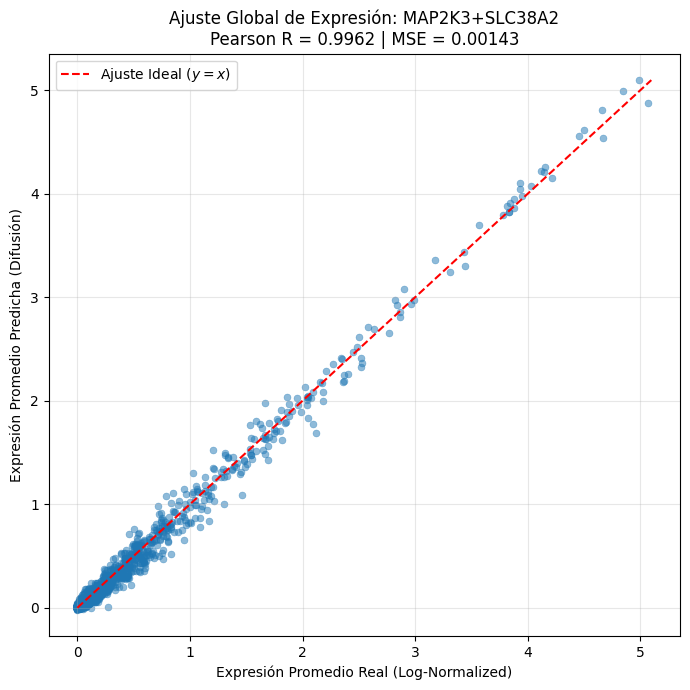

In [ ]:
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Calculamos métricas
r_val, _ = stats.pearsonr(perfil_medio_real, perfil_medio_pred)
mse_val = np.mean((perfil_medio_real - perfil_medio_pred) ** 2)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=perfil_medio_real, y=perfil_medio_pred, alpha=0.5, color='#1f77b4', edgecolor=None, s=25)

# Línea de identidad ideal y=x
max_val = max(perfil_medio_real.max(), perfil_medio_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5, label='Ajuste Ideal ($y=x$)')

plt.title(f'Ajuste Global de Expresión: {CONDICION_A_TESTEAR}\nPearson R = {r_val:.4f} | MSE = {mse_val:.5f}', fontsize=12)
plt.xlabel('Expresión Promedio Real (Log-Normalized)', fontsize=10)
plt.ylabel('Expresión Promedio Predicha (Difusión)', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

COMPROBACIÓN DE GENES TARGET PARA: MAP2K3+SLC38A2
Gen: ENSG00000106028
   -> Expresión en Control (Gris):     1.4942
   -> Expresión Real Tratado (Azul):   1.7756  (Cambio: +0.2815)
   -> Predicción Difusión (Naranja):  1.8548  (Cambio: +0.3606)
----------------------------------------------------------------
Gen: ENSG00000123131
   -> Expresión en Control (Gris):     1.1883
   -> Expresión Real Tratado (Azul):   1.4712  (Cambio: +0.2829)
   -> Predicción Difusión (Naranja):  1.5188  (Cambio: +0.3304)
----------------------------------------------------------------
Gen: ENSG00000167996
   -> Expresión en Control (Gris):     4.4454
   -> Expresión Real Tratado (Azul):   4.1595  (Cambio: -0.2859)
   -> Predicción Difusión (Naranja):  4.1512  (Cambio: -0.2942)
----------------------------------------------------------------
Gen: ENSG00000041357
   -> Expresión en Control (Gris):     1.5264
   -> Expresión Real Tratado (Azul):   1.8151  (Cambio: +0.2887)
   -> Predicción Difusión (Naranja)

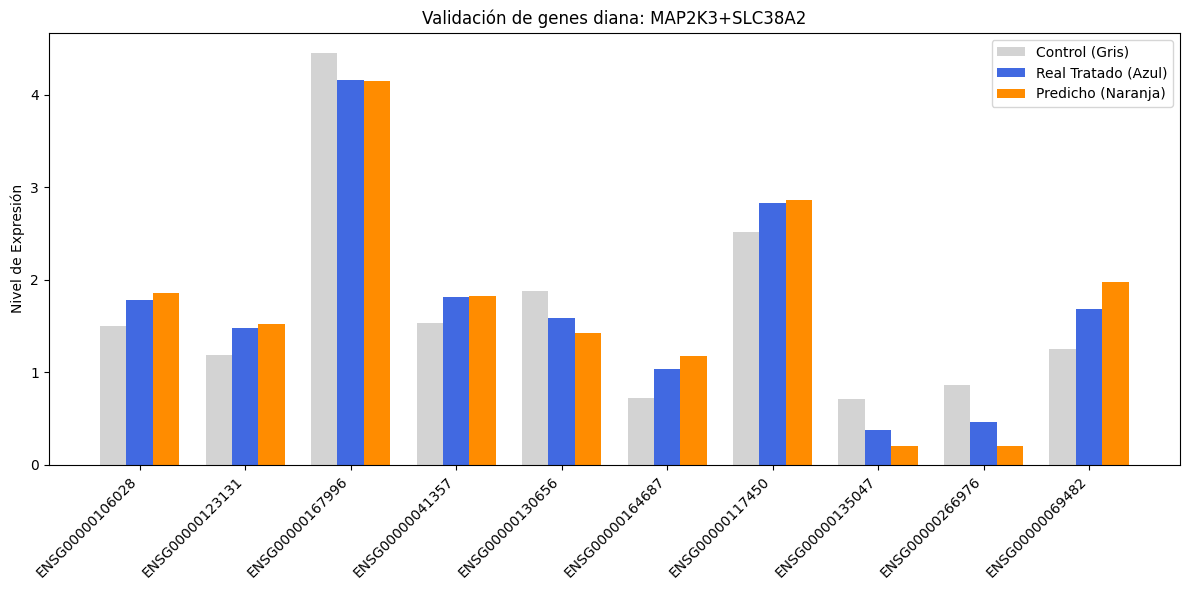

In [ ]:
import matplotlib.pyplot as plt

# Grupo A: Controles Reales (Línea base)
idx_ctrl = np.where(adata.obs['condition'].values == 'ctrl')[0]
X_ctrl = adata.X[idx_ctrl]
if sp.issparse(X_ctrl):
    X_ctrl = X_ctrl.toarray()

# Grupo B: Tratadas Reales (La realidad biológica)
idx_treated = np.where(adata.obs['condition'].values == CONDICION_A_TESTEAR)[0]
X_treated_real = adata.X[idx_treated]
if sp.issparse(X_treated_real):
    X_treated_real = X_treated_real.toarray()

# Calculamos el perfil medio de Control (Gris) y Tratado Real (Azul)
perfil_ctrl = np.mean(X_ctrl, axis=0)
perfil_real = np.mean(X_treated_real, axis=0)
perfil_sintetico = np.mean(X_predicho, axis=0) # Tus células naranjas

# Encontramos qué genes sufrieron el mayor cambio real (pueden subir o bajar)
cambio_biologico_real = perfil_real - perfil_ctrl
indices_top_genes = np.argsort(np.abs(cambio_biologico_real))[-10:] # Los 10 que más cambian entre sin perturbacion y perturbado

print(f"COMPROBACIÓN DE GENES TARGET PARA: {CONDICION_A_TESTEAR}")
nombre_gen_list = []
val_control_list = []
val_real_list = []
val_predicho_list = []
for idx in indices_top_genes:
    nombre_gen = adata.var_names[idx] if hasattr(adata, 'var_names') else f"Gene_{idx}"

    val_control = perfil_ctrl[idx]
    val_real = perfil_real[idx]
    val_predicho = perfil_sintetico[idx]

    print(f"Gen: {nombre_gen}")
    print(f"   -> Expresión en Control (Gris):     {val_control:.4f}")
    print(f"   -> Expresión Real Tratado (Azul):   {val_real:.4f}  (Cambio: {val_real - val_control:+.4f})")
    print(f"   -> Predicción Difusión (Naranja):  {val_predicho:.4f}  (Cambio: {val_predicho - val_control:+.4f})")
    print("-" * 64)
    nombre_gen_list.append(nombre_gen)
    val_control_list.append(val_control)
    val_real_list.append(val_real)
    val_predicho_list.append(val_predicho)

# Grafico
x = np.arange(len(nombre_gen_list))  # Índices para los genes
ancho = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - ancho, val_control_list, width=ancho, label='Control (Gris)', color='lightgray')
plt.bar(x, val_real_list, width=ancho, label='Real Tratado (Azul)', color='royalblue')
plt.bar(x + ancho, val_predicho_list, width=ancho, label='Predicho (Naranja)', color='darkorange')

plt.xticks(x, nombre_gen_list, rotation=45, ha='right')
plt.ylabel('Nivel de Expresión')
plt.title(f'Validación de genes diana: {CONDICION_A_TESTEAR}')
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
def analizar_perturbacion(condicion, adata_split, latentes_split, nombre_split,t = 0.7, gs = 3):
    print(f"\n--- Analizando: {condicion} en {nombre_split} ---")

    # Preparar controles y vectores de intervención
    idx_ctrl = np.where(adata_split.obs['condition'].values == 'ctrl')[0]
    latentes_control = latentes_split[idx_ctrl].to(device)

    vector_target = torch.zeros((1, INTERVENTION_DIM), dtype=torch.float32).to(device)
    for gen in condicion.split('+'):
        if gen in gene_to_idx:
            vector_target[0, gene_to_idx[gen]] = 1.0
    vector_intervencion = vector_target.repeat(latentes_control.shape[0], 1)
    autoencoder.eval()
    modelo_difusion.eval()
    with torch.no_grad():
    # Inferencia (CFG)
       z_pred = predecir_perturbacion_guidance(modelo_difusion, latentes_control, vector_intervencion,
                                            t_start= t, num_steps=30, guidance_scale= gs)

    # Decodificar
       z_pred_unscaled = escalador.inverse_transform(z_pred.cpu().numpy())
       X_pred = autoencoder.decoder(torch.tensor(z_pred_unscaled).float().to(device)).cpu().detach().numpy()

    # Extraer datos reales para comparar
    idx_reales = np.where(adata_split.obs['condition'].values == condicion)[0]
    if len(idx_reales) == 0: return None, None, None, None

    X_real = adata_split.X[idx_reales].toarray() if sp.issparse(adata_split.X) else adata_split.X[idx_reales]

    # Retornar perfiles medios
    return np.mean(adata_split.X[idx_ctrl].toarray() if sp.issparse(adata_split.X) else adata_split.X[idx_ctrl], axis=0), \
           np.mean(X_real, axis=0), np.mean(X_pred, axis=0), condicion



adata_val = adata_train[obs_val.index].copy()

# Selecionamos 5 perturbaciones para ver como lo hace el modelo
# Extraemos condiciones únicas de validación, excluyendo el control
condiciones_disponibles = [c for c in adata_val.obs['condition'].unique() if c != 'ctrl']


Top 5 intervenciones con mayor impacto biológico:
 - JUN+CEBPA: 2.3532
 - CBL+CNN1: 2.0079
 - IKZF3+ctrl: 1.9655
 - CEBPE+SPI1: 1.9361
 - DUSP9+KLF1: 1.8844

--- Analizando: JUN+CEBPA en Validación Múltiple (Top Impacto Top 5) ---

--- Condición: JUN+CEBPA ---
Impacto medio del Top 5 : 2.3532
MSE Top 5 Genes         : 4.182032


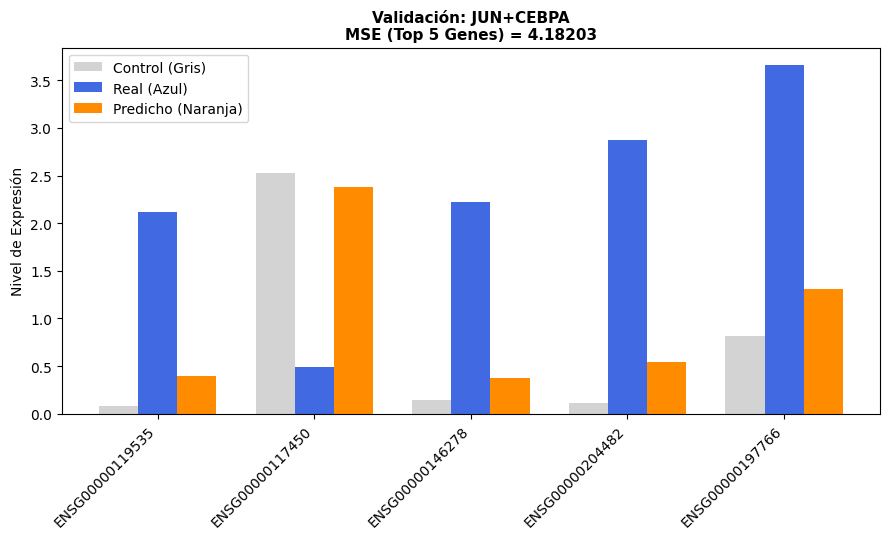


--- Analizando: CBL+CNN1 en Validación Múltiple (Top Impacto Top 5) ---

--- Condición: CBL+CNN1 ---
Impacto medio del Top 5 : 2.0079
MSE Top 5 Genes         : 0.110166


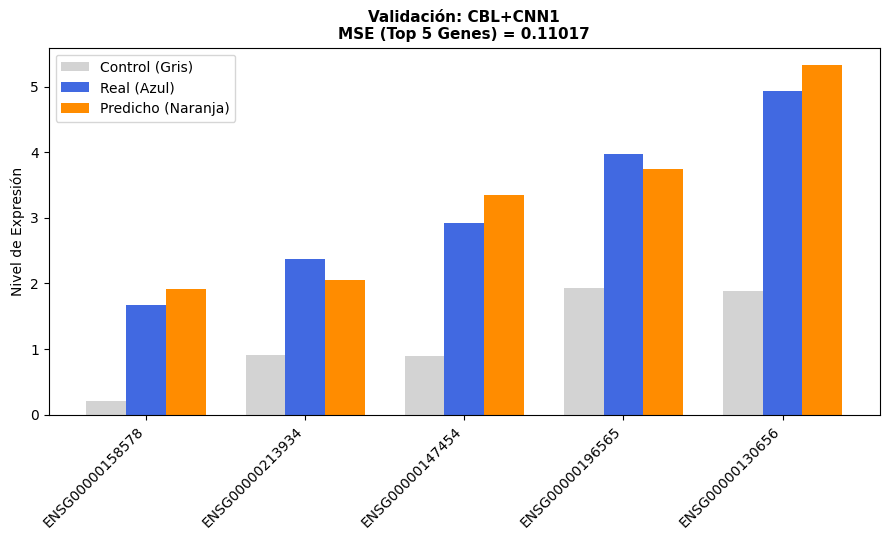


--- Analizando: IKZF3+ctrl en Validación Múltiple (Top Impacto Top 5) ---

--- Condición: IKZF3+ctrl ---
Impacto medio del Top 5 : 1.9655
MSE Top 5 Genes         : 0.214145


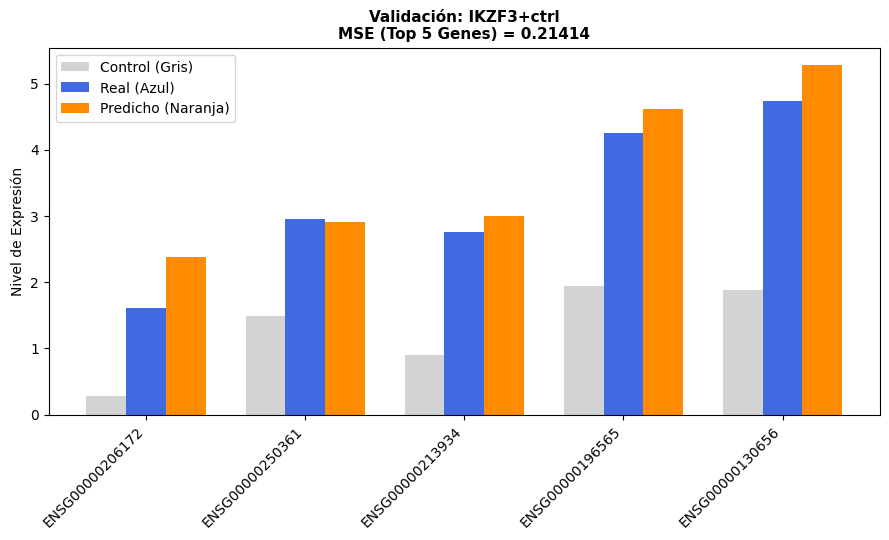


--- Analizando: CEBPE+SPI1 en Validación Múltiple (Top Impacto Top 5) ---

--- Condición: CEBPE+SPI1 ---
Impacto medio del Top 5 : 1.9361
MSE Top 5 Genes         : 0.678881


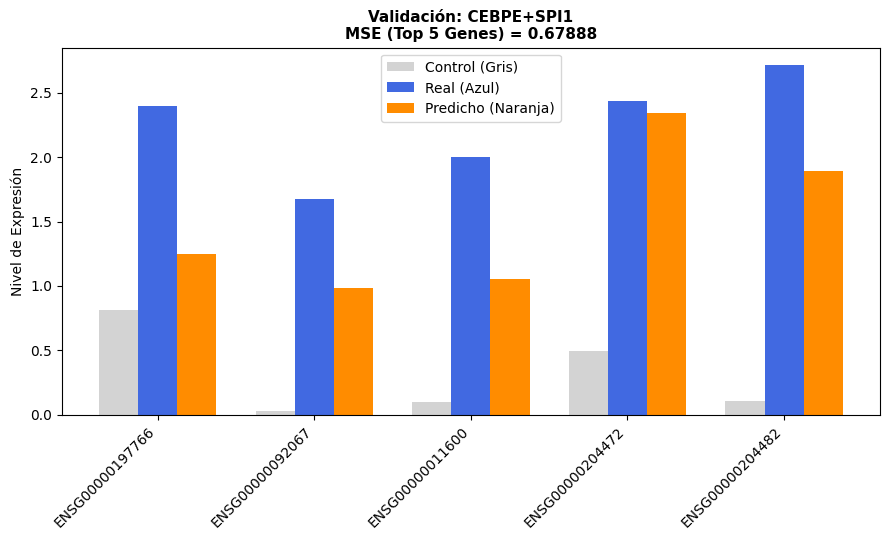


--- Analizando: DUSP9+KLF1 en Validación Múltiple (Top Impacto Top 5) ---

--- Condición: DUSP9+KLF1 ---
Impacto medio del Top 5 : 1.8844
MSE Top 5 Genes         : 0.056621


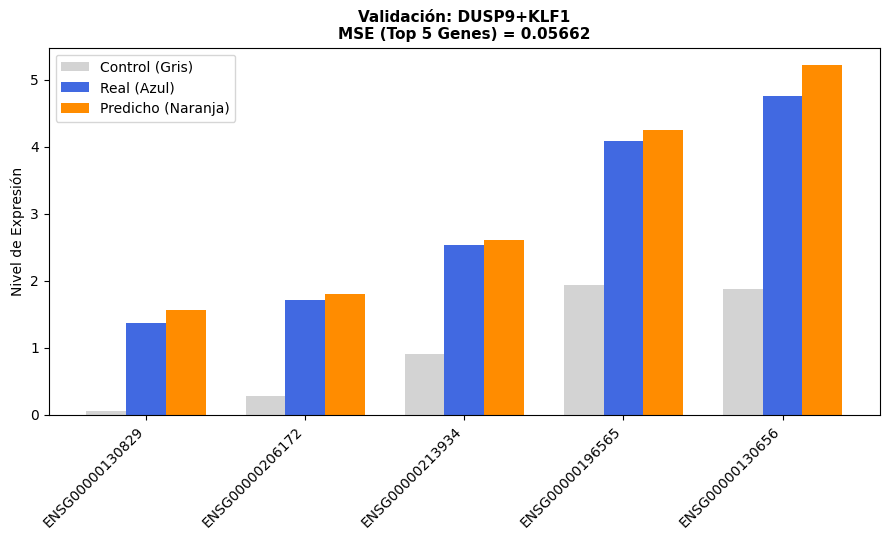

In [ ]:
import scipy.sparse as sp


# Perfil medio del grupo Control
idx_ctrl = np.where(adata_val.obs['condition'].values == 'ctrl')[0]
X_ctrl = adata_val.X[idx_ctrl].toarray() if sp.issparse(adata_val.X) else adata_val.X[idx_ctrl]
p_ctrl_global = np.mean(X_ctrl, axis=0)

# Magnitud del cambio enfocándonos SOLO en el Top 5 de cada condición
impacto_condiciones = []
condiciones_disponibles = [c for c in adata_val.obs['condition'].unique() if c != 'ctrl']

for cond in condiciones_disponibles:
    idx_real = np.where(adata_val.obs['condition'].values == cond)[0]
    if len(idx_real) > 0:
        X_real = adata_val.X[idx_real].toarray() if sp.issparse(adata_val.X) else adata_val.X[idx_real]
        p_real = np.mean(X_real, axis=0)

        # Diferencia absoluta gen a gen respecto al control
        delta_genes = np.abs(p_real - p_ctrl_global)

        # Promedio de cambio enfocado SOLO en 5 genes que más cambian
        top5_deltas = np.sort(delta_genes)[-5:]
        magnitud_cambio_top5 = np.mean(top5_deltas)

        impacto_condiciones.append({'condicion': cond, 'impacto': magnitud_cambio_top5})

# Ordenamos de mayor a menor impacto (basado en el Top 5) y seleccionamos las Top 5
impacto_condiciones.sort(key=lambda x: x['impacto'], reverse=True)
condiciones_top5 = [item['condicion'] for item in impacto_condiciones[:5]]

print("Top 5 intervenciones con mayor impacto biológico:")
for item in impacto_condiciones[:5]:
    print(f" - {item['condicion']}: {item['impacto']:.4f}")

# Bucle de graficación
tareas_multiples = []
for cond in condiciones_top5:
    tareas_multiples.append((cond, adata_val, Z_val_tensor, 'Validación Múltiple (Top Impacto Top 5)'))

# Bucle de Inferencia, Cálculo de MSE y Gráficos
for cond, adata_s, z_s, nombre_split in tareas_multiples:
    p_ctrl, p_real, p_pred, name = analizar_perturbacion(cond, adata_s, z_s, nombre_split, t = 0.9 , gs = 2.0 )

    # Extraer los índices de los Top 5 genes que más cambiaron
    delta = np.abs(p_real - p_ctrl)
    top_indices = np.argsort(delta)[-5:]

    # MSE enfocado en los 5 genes más impactados
    mse_top5 = np.mean((p_real[top_indices] - p_pred[top_indices]) ** 2)
    # MSE global
    mse_global = np.mean((p_real - p_pred) ** 2)

    print(f"\n--- Condición: {name} ---")
    print(f"Impacto medio del Top 5 : {np.mean(delta[top_indices]):.4f}")
    print(f"MSE Top 5 Genes         : {mse_top5:.6f}")



# GRAFICO
    genes = [adata_s.var_names[i] for i in top_indices]
    x = np.arange(len(genes))
    w = 0.25

    plt.figure(figsize=(9, 5.5))
    plt.bar(x - w, p_ctrl[top_indices], w, label='Control (Gris)', color='lightgray')
    plt.bar(x, p_real[top_indices], w, label='Real (Azul)', color='royalblue')
    plt.bar(x + w, p_pred[top_indices], w, label='Predicho (Naranja)', color='darkorange')

    plt.xticks(x, genes, rotation=45, ha='right')
    plt.ylabel("Nivel de Expresión")
    plt.title(f"Validación: {name}\n"
              f"MSE (Top 5 Genes) = {mse_top5:.5f}",
              fontsize=11, fontweight='bold')

    plt.legend()
    plt.tight_layout()
    plt.show()

Condiciones OOD a evaluar: ['KLF1+MAP2K6', 'ARID1A+ctrl']

--- Evaluando condición OOD: KLF1+MAP2K6 ---


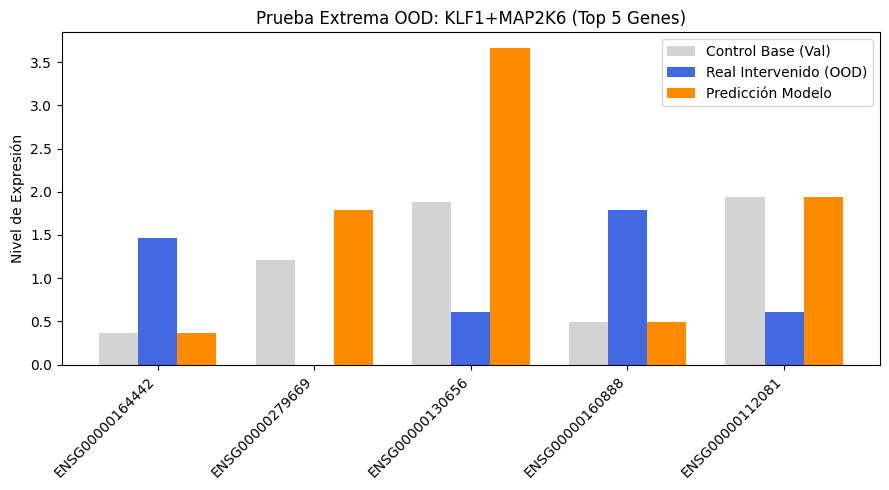


--- Evaluando condición OOD: ARID1A+ctrl ---


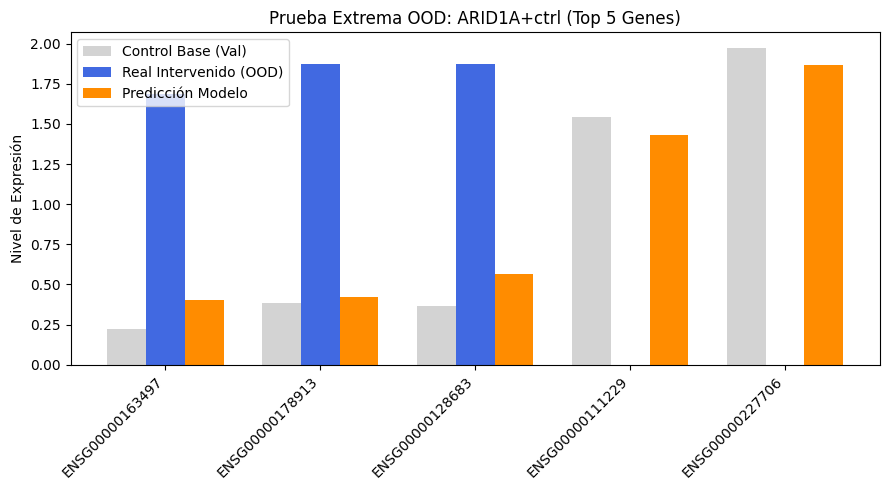

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch

# 1. Obtenemos las células control de validación
idx_controles_val = np.where(obs_val['condition'].values == 'ctrl')[0]
latentes_control = Z_val_tensor[idx_controles_val].to(device)

# Guardamos su expresión real para comparar luego
X_ctrl_real = adata_val.X[idx_controles_val]
if sp.issparse(X_ctrl_real):
    X_ctrl_real = X_ctrl_real.toarray()
perfil_ctrl = np.mean(X_ctrl_real, axis=0)

# Parámetros de la difusión
num_steps_test = 30

condiciones_ood = [c for c in adata_ood.obs['condition'].unique() if c != 'ctrl']
print(f"Condiciones OOD a evaluar: {condiciones_ood}")

for condicion in condiciones_ood:
    print(f"\n--- Evaluando condición OOD: {condicion} ---")

    # 2. Construimos el vector de intervención para esta condición OOD
    vector_intervencion_target = torch.zeros((1, INTERVENTION_DIM), dtype=torch.float32).to(device)
    for gen in condicion.split('+'):
        if gen in gene_to_idx:
            vector_intervencion_target[0, gene_to_idx[gen]] = 1.0

    # Repetimos el vector para que coincida con el número de células control
    vector_intervencion_batch = vector_intervencion_target.repeat(latentes_control.shape[0], 1)

    z_predichos_scaled = predecir_perturbacion_guidance(
        model=modelo_difusion,
        latentes_base=latentes_control,
        intervention_vector=vector_intervencion_batch,
        t_start=0.9,
        num_steps=num_steps_test,
        guidance_scale= 2
    )

    # 4. Decodificamos el resultado
    z_predichos_numpy = z_predichos_scaled.cpu().numpy()
    z_predichos_unscaled = escalador.inverse_transform(z_predichos_numpy)
    z_predichos_tensor = torch.tensor(z_predichos_unscaled, dtype=torch.float32).to(device)

    autoencoder.eval()
    with torch.no_grad():
        X_predicho = autoencoder.decoder(z_predichos_tensor).cpu().numpy()

    perfil_pred = np.mean(X_predicho, axis=0)

    # Obtenemos las células reales perturbadas desde adata_ood
    idx_reales_ood = np.where(adata_ood.obs['condition'].values == condicion)[0]

    X_real_ood = adata_ood.X[idx_reales_ood]
    if sp.issparse(X_real_ood):
        X_real_ood = X_real_ood.toarray()

    perfil_real = np.mean(X_real_ood, axis=0)

    delta = np.abs(perfil_real - perfil_ctrl)
    top_indices = np.argsort(delta)[-5:]

    genes = [adata_ood.var_names[i] for i in top_indices]
    x = np.arange(len(genes))
    w = 0.25

    plt.figure(figsize=(9, 5))
    plt.bar(x - w, perfil_ctrl[top_indices], w, label='Control Base (Val)', color='lightgray')
    plt.bar(x, perfil_real[top_indices], w, label='Real Intervenido (OOD)', color='royalblue')
    plt.bar(x + w, perfil_pred[top_indices], w, label='Predicción Modelo', color='darkorange')

    plt.xticks(x, genes, rotation=45, ha='right')
    plt.title(f"Prueba Extrema OOD: {condicion} (Top 5 Genes)")
    plt.ylabel("Nivel de Expresión")
    plt.legend()
    plt.tight_layout()
    plt.show()


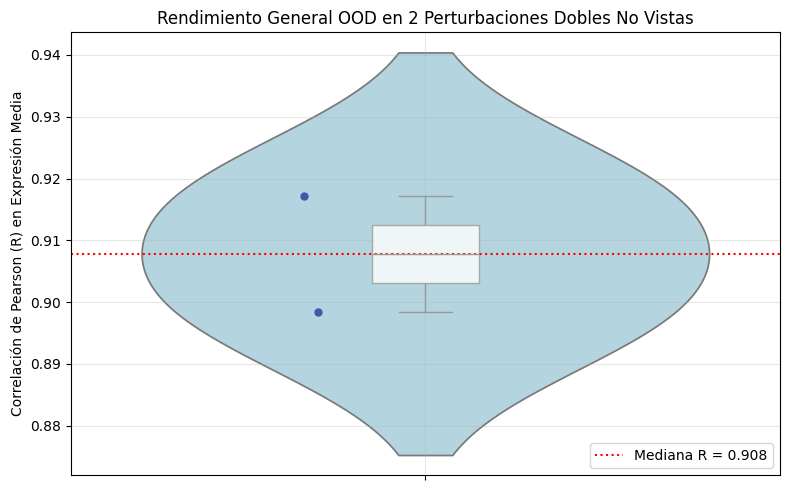

In [ ]:
import pandas as pd
import seaborn as sns

resultados_ood = []

condiciones_ood = [c for c in adata_ood.obs['condition'].unique() if c != 'ctrl']

for cond in condiciones_ood:
    # 1. Preparar vector de intervención
    vector_target = torch.zeros((1, INTERVENTION_DIM), dtype=torch.float32).to(device)
    for gen in cond.split('+'):
        if gen in gene_to_idx:
            vector_target[0, gene_to_idx[gen]] = 1.0

    vec_batch = vector_target.repeat(latentes_control.shape[0], 1)

    # 2. Inferencia
    with torch.no_grad():
        z_pred = predecir_perturbacion_guidance(
            modelo_difusion, latentes_control, vec_batch,
            t_start=0.7, num_steps=30, guidance_scale=3
        )
        z_unscaled = escalador.inverse_transform(z_pred.cpu().numpy())
        X_pred = autoencoder.decoder(torch.tensor(z_unscaled).float().to(device)).cpu().numpy()

    # 3. Comparar con real
    idx_reales = np.where(adata_ood.obs['condition'].values == cond)[0]
    if len(idx_reales) > 0:
        X_real = adata_ood.X[idx_reales].toarray() if sp.issparse(adata_ood.X) else adata_ood.X[idx_reales]

        p_real = np.mean(X_real, axis=0)
        p_pred = np.mean(X_pred, axis=0)

        r, _ = stats.pearsonr(p_real, p_pred)
        resultados_ood.append({'Condicion': cond, 'Pearson_R': r})

df_ood = pd.DataFrame(resultados_ood)

# Gráfica de Distribución (Violin + Boxplot)
plt.figure(figsize=(8, 5))
sns.violinplot(y=df_ood['Pearson_R'], color='lightblue', inner=None)
sns.boxplot(y=df_ood['Pearson_R'], color='white', width=0.15, boxprops=dict(alpha=0.8))
sns.stripplot(y=df_ood['Pearson_R'], color='darkblue', alpha=0.6, jitter=0.2, size=6)

plt.title(f'Rendimiento General OOD en {len(df_ood)} Perturbaciones Dobles No Vistas', fontsize=12)
plt.ylabel('Correlación de Pearson (R) en Expresión Media', fontsize=10)
plt.axhline(df_ood['Pearson_R'].median(), color='red', linestyle=':', label=f'Mediana R = {df_ood["Pearson_R"].median():.3f}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()